In [2]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [3]:
im_or = cv2.imread("PirabasB_2 - Copy.tif")

In [4]:
im_or.shape


(768, 1024, 3)

In [5]:
im_or.min(), im_or.max()

(0, 255)

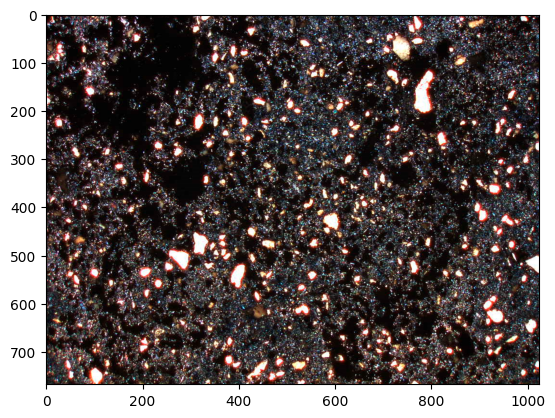

In [6]:
plt.imshow(im_or)

In [7]:
import cv2
# Convert the image to grayscale
grayscale_image = cv2.cvtColor(im_or, cv2.COLOR_BGR2GRAY)

In [8]:
grayscale_image.shape

(768, 1024)

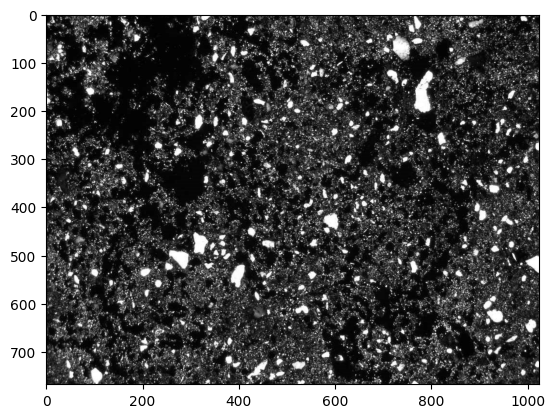

In [9]:
plt.imshow(grayscale_image, cmap="gray")

In [10]:
# Let's see the data as each vector (features) to a regression model
x_weidth, y_height = grayscale_image.shape
grayscale_image.shape, x_weidth, y_height

((768, 1024), 768, 1024)

In [11]:
range(0,x_weidth), range(0, y_height)

(range(0, 768), range(0, 1024))

In [12]:
# Generate the model
# Save each characteristic of the image as features (the pixel value, axis x and y);
pixels_values = [];
axis_x_vector = [];
axis_y_vector = [];

for ii in range(0,x_weidth):
  for jj in range(0,y_height):
    pixel_value_temp = grayscale_image[ii,jj]
    ii_temp = ii
    jj_temp = jj
    pixels_values.append(pixel_value_temp)
    axis_x_vector.append(ii_temp)
    axis_y_vector.append(jj_temp)

In [13]:
len(pixels_values), len(axis_x_vector), len(axis_y_vector)

(786432, 786432, 786432)

In [14]:
import random
Random_values= random.randint(0,len(pixels_values))
Random_values

717412

In [15]:
print("The index", Random_values)
#Checkinf the values and the spatial variation
pixels_values[Random_values] == grayscale_image[axis_x_vector[Random_values],axis_y_vector[Random_values]]

The index 717412


True

In [16]:
#Convert to a numpy array
pixels_values =np.array(pixels_values)
axis_x_vector = np.array(axis_x_vector)
axis_y_vector = np.array(axis_y_vector)

In [17]:
#check the range of the values
pixels_values.min(), pixels_values.max()

(0, 255)

In [18]:
#Let's normalize the data
pixels_values_normalize = (pixels_values - pixels_values.min())/(pixels_values.max() - pixels_values.min())

In [19]:
pixels_values_normalize.min(), pixels_values_normalize.max()

(0.0, 1.0)

In [20]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Prepare the input features by stacking the axis vectors and reshaping for CNN
X = np.column_stack((axis_x_vector, axis_y_vector)).reshape(-1, 2, 1)
y = pixels_values_normalize
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the CNN model
model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(2, 1)),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer=Adam(), loss='mean_squared_error')

In [21]:
# In that case the X will be pars of axis_x_vector and axis_y_vector
# for instance: [axis_x_vector[0], axis_y_vector[0],..., axis_x_vector[n], axis_y_vector[n] ]
X.shape, y.shape

((786432, 2, 1), (786432,))

In [19]:
# Train the model
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
17204/17204 [==============================] - 42s 2ms/step - loss: 4.5530
Epoch 2/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0953
Epoch 3/10
17204/17204 [==============================] - 42s 2ms/step - loss: 0.0605
Epoch 4/10
17204/17204 [==============================] - 42s 2ms/step - loss: 0.0527
Epoch 5/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 6/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 7/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 8/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 9/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 10/10
7373/7373 [==============================] - 6s 818us/step
Mean Squared Error: 0.0524507139025643
Predicted values: [0.20665552 0.20665552 0.20665552 ... 0.20665552 0.20665552 0.20665552]
Actual values: [0.05098039

In [55]:
X_test.shape

(235930, 2, 1)

In [20]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Display predictions
print(f'Predicted values: {y_pred.flatten()}')
print(f'Actual values: {y_test}')

7373/7373 [==============================] - 6s 778us/step
Mean Squared Error: 0.0524507139025643
Predicted values: [0.20665552 0.20665552 0.20665552 ... 0.20665552 0.20665552 0.20665552]
Actual values: [0.05098039 0.84313725 0.16470588 ... 0.20392157 0.00784314 0.16470588]


In [23]:
len(y_pred), len(X_test)

(235930, 235930)

## Predict the original image with the model

In [26]:
im_or.shape, grayscale_image.shape

((768, 1024, 3), (768, 1024))

In [27]:
grayscale_image.min(), grayscale_image.max()

(0, 255)

In [28]:
# Normalize the data
grayscale_image_normalized = (grayscale_image - grayscale_image.min())/(grayscale_image.max() - grayscale_image.min())

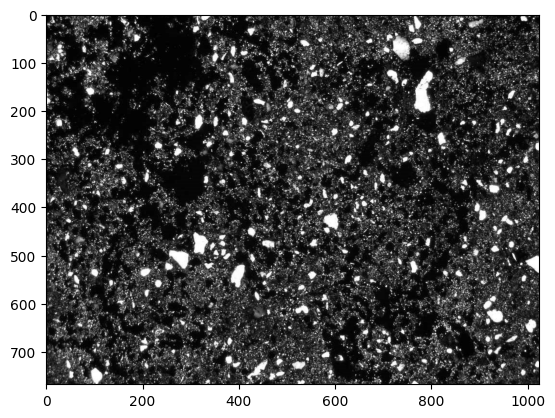

In [29]:
plt.imshow(grayscale_image_normalized, cmap = "gray")

In [30]:
## Let's use the model to reconstruct the image
# Prepare the input features by stacking the axis vectors and reshaping for CNN
X_feature_to_predicit = np.column_stack((axis_x_vector, axis_y_vector)).reshape(-1, 2, 1)

In [31]:
# Make predictions
y_pred_values = model.predict(X_feature_to_predicit)


24576/24576 [==============================] - 23s 934us/step


In [32]:
import numpy as np

# Initialize an empty image array with the same dimensions as the original image
reconstructed_image = np.zeros((x_weidth, y_height), dtype=np.uint8)

# Iterate through the vectors and place each pixel value back into its position
for k in range(len(y_pred_values)):
    ii = axis_x_vector[k]
    jj = axis_y_vector[k]
    reconstructed_image[ii, jj] = pixels_values[k]

# The reconstructed_image now holds the original image


In [33]:
reconstructed_image.shape

(768, 1024)

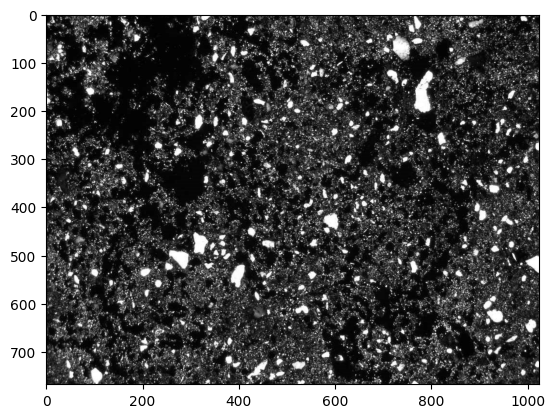

In [34]:
plt.imshow(reconstructed_image, cmap="gray")

In [38]:
grayscale_image.min(), grayscale_image.max(), reconstructed_image.min(), reconstructed_image.max()

(0, 255, 0, 255)

In [39]:
grayscale_image == reconstructed_image

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [46]:
c_false = 0
c_true = 0
for ii in range(0,x_weidth):
  for jj in range(0,y_height):
    temp_bool = grayscale_image[ii,jj] == reconstructed_image[ii,jj]
    if temp_bool == False:
        c_false = c_false + 1
    elif temp_bool == True:
        c_true = c_true + 1
        


In [49]:
c_true == len(axis_x_vector), c_false, c_true, len(axis_x_vector)

(True, 0, 786432, 786432)

In [51]:
# Function to reconstruct the original image and mask
import numpy as np

def jaccard_similarity(image, image_2):
    # Flatten the images to 1D arrays
    image_flat = image.flatten()
    image_2_flat = image_2.flatten()

    # Calculate intersection (number of matching pixels)
    intersection = np.sum(np.logical_and(image_flat, image_2_flat))

    # Calculate union (number of pixels marked as foreground in either image or mask)
    union = np.sum(np.logical_or(image_flat, image_2_flat))

    # Calculate Jaccard similarity coefficient
    jaccard = intersection / union

    return jaccard

In [54]:
jaccard_metric_or_rec = jaccard_similarity(grayscale_image, reconstructed_image)
print("The jaccard similarity between the original image and the reconstruct image is:", jaccard_metric_or_rec)

The jaccard similarity between the original image and the reconstruct image is: 1.0


## Apply the Difusion process: With Deep Learning

## Set the random seed to turn the models reproducible

In [2202]:
import tensorflow as tf
import numpy as np
import random

In [2203]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


In [2204]:
def make_deterministic(seed=42):
    set_seed(seed)
    # Configurar TensorFlow para comportamento determinístico
    session_config = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
    session_config.gpu_options.allow_growth = True
    tf.compat.v1.keras.backend.set_session(tf.compat.v1.Session(config=session_config))


In [2205]:
make_deterministic(seed=42)

## Preprocessing of the data: To the DCGAN

In [2206]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [2207]:
im_or = cv2.imread("PirabasB_2 - Copy.tif")

In [2208]:
im_or.shape


(768, 1024, 3)

In [2209]:
im_or.min(), im_or.max()

(0, 255)

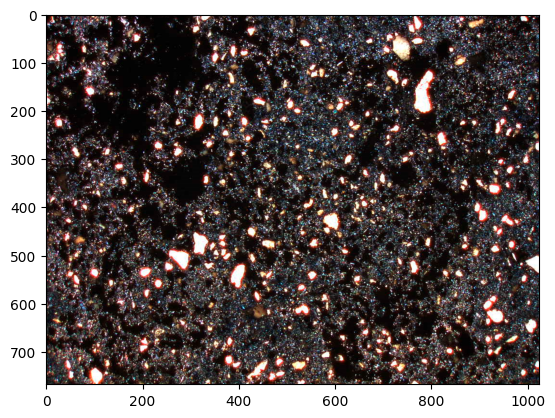

In [2210]:
plt.imshow(im_or)

In [2211]:
import cv2
# Convert the image to grayscale
grayscale_image = cv2.cvtColor(im_or, cv2.COLOR_BGR2GRAY)

In [2212]:
grayscale_image.shape

(768, 1024)

In [2213]:
grayscale_image.min(), grayscale_image.max()

(0, 255)

In [2214]:
norm_true = 1
if norm_true == 1:
    ##grayscale_image = (grayscale_image - grayscale_image.min())/ (grayscale_image.max() - grayscale_image.min())
    grayscale_image = (grayscale_image)/ (grayscale_image.max())
    print("The data was normalized")
else:
    print("The data was not normalized")    

The data was normalized


In [2215]:
grayscale_image.min(), grayscale_image.max()

(0.0, 1.0)

In [2216]:
def create_binary(img):
    import cv2
    # Apply a threshold to the grayscale image
    #threshold_value = 95
    threshold_value = img.mean() + 0.24 * img.mean()
    max_value = 1
    # Set the value 1 to be the pore space
    ret, binary = cv2.threshold(img, threshold_value, max_value, cv2.THRESH_BINARY)
    return binary

In [2217]:
segmentation_proc = 1
if segmentation_proc ==1:
    grayscale_image = create_binary(grayscale_image)
    print("The image was segmentated with thresold")
else:
    print("The image was not segmentated with thresold")    
    
    
    

The image was segmentated with thresold


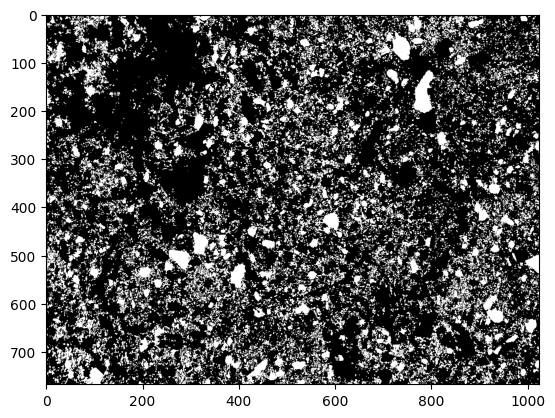

In [2218]:
plt.imshow(grayscale_image, cmap="gray")

In [2219]:
grayscale_image.min(), grayscale_image.max()

(0.0, 1.0)

In [2220]:
import numpy as np

def forward_process(image, timesteps, beta, norm_true):
    noisy_images = []
    for t in range(timesteps):
        noise = np.random.normal(0, beta, image.shape)
        image = image + noise
        if norm_true == 1:
            image = (image - image.min())/ (image.max() - image.min())
            #print("The data was normalized")
        else:
            False
            #print("The data was not normalized") 
        
        
        noisy_images.append(image)
    return noisy_images

def reverse_process(noisy_images, model):
    for t in reversed(range(len(noisy_images))):
        noisy_image = noisy_images[t]
        noise_estimate = model.predict(noisy_image)  # Modelo treinado para prever o ruído
        noisy_image = noisy_image - noise_estimate
    return noisy_image

In [2221]:
import numpy as np

def samples_generate_clean_process(image, timesteps, beta):
    clean_images = []
    for t in range(timesteps):
        clean_images.append(image)
    return clean_images


In [2222]:
# Process de difusão progressiva
# Exemplo de uso
timesteps = 150 # We have the 200 samples
timesteps_clean = 300
beta = 0.10
norm_true = 1
noisy_images = forward_process(grayscale_image, timesteps, beta, norm_true)
clean_images = samples_generate_clean_process(grayscale_image, timesteps_clean, beta)

In [2223]:
len(noisy_images)

150

In [2224]:
noisy_images = np.array(noisy_images)
clean_images = np.array(clean_images)
noisy_images.shape, clean_images.shape

((150, 768, 1024), (300, 768, 1024))

In [1957]:
noisy_images.min(), noisy_images.max()

(0.0, 1.0)

In [1958]:
## Check the range values to normalize the data
clean_images.min(), clean_images.max(), noisy_images.min() , noisy_images.max()

(0.0, 1.0, 0.0, 1.0)

In [1959]:
len(clean_images)

300

127


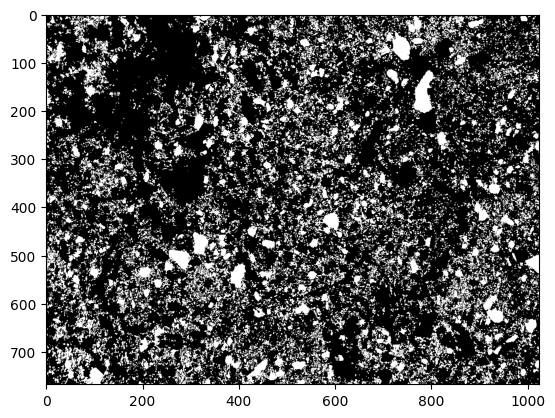

In [1960]:
import random 
idx_show_samples = random.randint(0,len(clean_images)) # without range incluse the max values 
print(idx_show_samples)
plt.imshow(clean_images[idx_show_samples, :, :], cmap="gray")

49


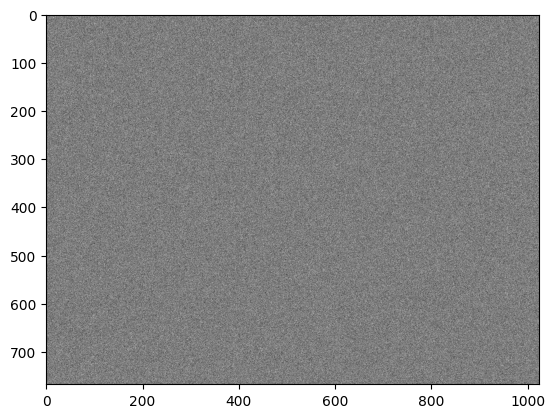

In [1961]:
import random 
idx_show_samples = random.randint(0,len(noisy_images)) # without range incluse the max values 
print(idx_show_samples)
plt.imshow(noisy_images[idx_show_samples, :, :], cmap="gray")

In [1962]:
## Check the range values to normalize the data
clean_images.min(), clean_images.max(), noisy_images.min() , noisy_images.max()

(0.0, 1.0, 0.0, 1.0)

In [1963]:
# Concatenate along the first axis (axis=0)
combined_images = np.concatenate([clean_images, noisy_images], axis=0)
combined_images.shape

(450, 768, 1024)

In [1964]:
import numpy as np

# Assuming noisy_images is your tensor of shape (200, 768, 1024)
shuffled_indices = np.random.permutation(combined_images.shape[0])
combined_images_shuffled = combined_images[shuffled_indices]
# Now noisy_images_shuffled contains the noisy images shuffled along the first axis (samples)


In [1965]:
combined_images_shuffled.shape

(450, 768, 1024)

97
The max and min value of the noisy image 0.0 1.0


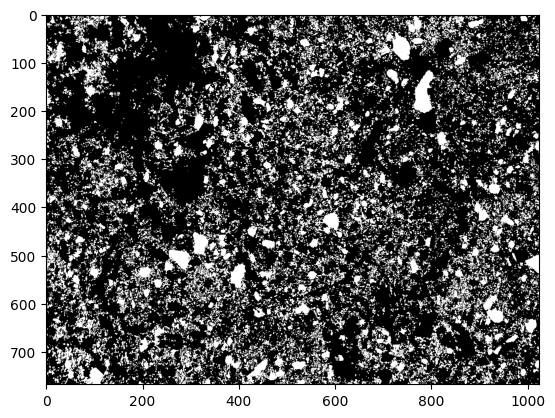

In [1966]:
import random
index_combined_images_shuffled = random.randint(0,len(combined_images_shuffled)-1)
print(index_combined_images_shuffled)
plt.imshow(combined_images_shuffled[index_combined_images_shuffled,:, :], cmap="gray")
print("The max and min value of the noisy image", combined_images_shuffled[index_combined_images_shuffled,:, :].min(), combined_images_shuffled[index_combined_images_shuffled,:, :].max())

In [1967]:
## Pressão, velocidade and modulo elástico.
## Try to introduce this information in the model

## Deep Convolutional GAN (DCGAN). 

### First model DCGAN

In [2040]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Sequential

# Constants
#BATCH_SIZE = 2  # Adjust batch size as needed
IMAGE_SHAPE = (768, 1024, 1)  # Assuming grayscale images

def build_generator():
    model = Sequential()

    # Encoder
    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu', input_shape=IMAGE_SHAPE))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    
    # Decoder
    model.add(Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(1, kernel_size=3, strides=1, padding='same', activation='sigmoid'))

    return model


In [2041]:
def build_discriminator():
    model = Sequential()

    # Convolutional layers
    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu', input_shape=IMAGE_SHAPE))
    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(Conv2D(128, kernel_size=3, strides=2, padding='same', activation='relu'))

    # Flatten and classify
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model


### Second model DCGAN

In [2042]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Sequential

# Constants
#BATCH_SIZE = 2  # Adjust batch size as needed
IMAGE_SHAPE = (768, 1024, 1)  # Assuming grayscale images


def build_generator():
    model = Sequential()

    # Encoder
    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu', input_shape=IMAGE_SHAPE))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, kernel_size=3, strides=2, padding='same', activation='relu'))  # Camada extra no encoder
    model.add(BatchNormalization())
    
    # Decoder
    model.add(Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu'))  # Camada extra no decoder
    model.add(BatchNormalization())
    model.add(Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(1, kernel_size=3, strides=1, padding='same', activation='sigmoid'))

    return model


In [2043]:
def build_discriminator():
    model = Sequential()

    # Convolutional layers
    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu', input_shape=IMAGE_SHAPE))
    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(Conv2D(128, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(Conv2D(256, kernel_size=3, strides=2, padding='same', activation='relu'))  # Camada extra

    # Flatten and classify
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model


### Compile and the train

In [2044]:
generator = build_generator()
generator.compile(optimizer='adam', loss='mse')

discriminator = build_discriminator()
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#discriminator.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

In [2045]:
discriminator.trainable = False  # Freeze the discriminator during GAN training

gan_input = tf.keras.Input(shape=IMAGE_SHAPE)
generated_image = generator(gan_input)
gan_output = discriminator(generated_image)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')
#gan.compile(optimizer='adam', loss='mse')

In [2046]:
import numpy as np

# Assuming noisy_images is already loaded and has shape (300, 768, 1024)
combined_images_shuffled = np.expand_dims(combined_images_shuffled, axis=-1)  # Add channel dimension

In [2047]:
combined_images_shuffled.shape

(450, 768, 1024, 1, 1)

In [2048]:
# num_batches = 16  # Adjust batch size as needed
# IMAGE_SHAPE = (768, 1024, 1)  # Assuming grayscale images
# num_epochs = 10

In [2049]:
# # Assuming noisy_images is your input data tensor
# # Reshape noisy_images to (300, 768, 1024, 1) if necessary
# # Train the GAN iteratively
# for epoch in range(num_epochs):
#     for batch in range(num_batches):
#         # Train discriminator on real data
#         real_images = noisy_images[batch * BATCH_SIZE : (batch + 1) * BATCH_SIZE]
#         real_labels = np.ones((BATCH_SIZE, 1))  # Labels for real images
        
#         discriminator_loss_real = discriminator.train_on_batch(real_images, real_labels)
        
#         # Train discriminator on generated (fake) data
#         noise = np.random.normal(0, 1, (BATCH_SIZE, *IMAGE_SHAPE))
#         generated_images = generator.predict(noise)
#         fake_labels = np.zeros((BATCH_SIZE, 1))  # Labels for fake images
        
#         discriminator_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
        
#         # Train generator (full GAN)
#         noise = np.random.normal(0, 1, (BATCH_SIZE, *IMAGE_SHAPE))
#         gan_labels = np.ones((BATCH_SIZE, 1))  # Labels for generated images (trick discriminator)
        
#         gan_loss = gan.train_on_batch(noise, gan_labels)
        
#         # Print progress
#         print(f"Epoch {epoch + 1}/{num_epochs}, Batch {batch}/{num_batches}, "
#               f"Discriminator Loss: {discriminator_loss_real[0] + discriminator_loss_fake[0]}, "
#               f"GAN Loss: {gan_loss}")


In [2050]:
BATCH_SIZE = 1
num_batches = 8  # Adjust batch size as needed
IMAGE_SHAPE = (768, 1024, 1)  # Assuming grayscale images
num_epochs = 100

In [1979]:
combined_images_shuffled.shape, combined_images_shuffled.dtype

((450, 768, 1024, 1), dtype('float64'))

In [1980]:
combined_images_shuffled = combined_images_shuffled.astype("float16")

In [1981]:
combined_images_shuffled.max(), combined_images_shuffled.min()

(1.0, 0.0)

In [1982]:
combined_images_shuffled.max(), combined_images_shuffled.min()

(1.0, 0.0)

In [1983]:
# To fix the error above:

# Assuming noisy_images is your input data tensor
# Reshape noisy_images to (300, 768, 1024, 1) if necessary
# Train the GAN iteratively
#with tf.device('/GPU:0'):
with tf.device('/GPU:0'):    
    for epoch in range(num_epochs):
        for batch in range(num_batches):
            # Train discriminator on real data
            real_images = combined_images_shuffled[batch * BATCH_SIZE : (batch + 1) * BATCH_SIZE]
            real_labels = np.ones((BATCH_SIZE, 1))  # Labels for real images
        
            discriminator_loss_real = discriminator.train_on_batch(real_images, real_labels)
        
            # Train discriminator on generated (fake) data
            noise = np.random.normal(0, 1, (BATCH_SIZE, *IMAGE_SHAPE))
            generated_images = generator.predict(noise)
            fake_labels = np.zeros((BATCH_SIZE, 1))  # Labels for fake images
        
            discriminator_loss_fake = discriminator.train_on_batch(generated_images, fake_labels)
        
            # Train generator (full GAN)
            noise = np.random.normal(0, 1, (BATCH_SIZE, *IMAGE_SHAPE))
            gan_labels = np.ones((BATCH_SIZE, 1))  # Labels for generated images (trick discriminator)
        
            gan_loss = gan.train_on_batch(noise, gan_labels)
        
            # Print progress
            print(f"Epoch {epoch + 1}/{num_epochs}, Batch {batch}/{num_batches}, "
                  f"Discriminator Loss: {discriminator_loss_real[0] + discriminator_loss_fake[0]}, "
                  f"GAN Loss: {gan_loss}")

1/1 [==============================] - 0s 117ms/step
Epoch 1/100, Batch 0/8, Discriminator Loss: 13.834312498569489, GAN Loss: 0.12881284952163696
1/1 [==============================] - 0s 17ms/step
Epoch 1/100, Batch 1/8, Discriminator Loss: 0.8395601063966751, GAN Loss: 0.987420916557312
1/1 [==============================] - 0s 17ms/step
Epoch 1/100, Batch 2/8, Discriminator Loss: 1.1501507759094238, GAN Loss: 0.18972498178482056
1/1 [==============================] - 0s 17ms/step
Epoch 1/100, Batch 3/8, Discriminator Loss: 2.287880539894104, GAN Loss: 0.003936138469725847
1/1 [==============================] - 0s 18ms/step
Epoch 1/100, Batch 4/8, Discriminator Loss: 0.8311050906777382, GAN Loss: 0.00402612192556262
1/1 [==============================] - 0s 17ms/step
Epoch 1/100, Batch 5/8, Discriminator Loss: 0.20054024072305765, GAN Loss: 0.009003374725580215
1/1 [==============================] - 0s 17ms/step
Epoch 1/100, Batch 6/8, Discriminator Loss: 0.05745152752206195, GAN Lo

In [1984]:
# After training, use the generator to denoise images
# Example code to denoise a single image:
def denoise_image(image):
    # Assuming 'image' is your input noisy image of shape (768, 1024, 1)
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    denoised_image = generator.predict(image)
    return denoised_image[0]

In [1985]:
import numpy as np

# Assuming noisy_images is already loaded and has shape (300, 768, 1024)
noisy_images_to_predict = np.expand_dims(noisy_images, axis=-1)  # Add channel dimension

In [1986]:
noisy_images.shape, noisy_images_to_predict.shape

((150, 768, 1024), (150, 768, 1024, 1))

In [1987]:
noisy_images_to_predict.max(), noisy_images_to_predict.min()

(1.0, 0.0)

The sample number 140
1/1 [==============================] - 0s 17ms/step


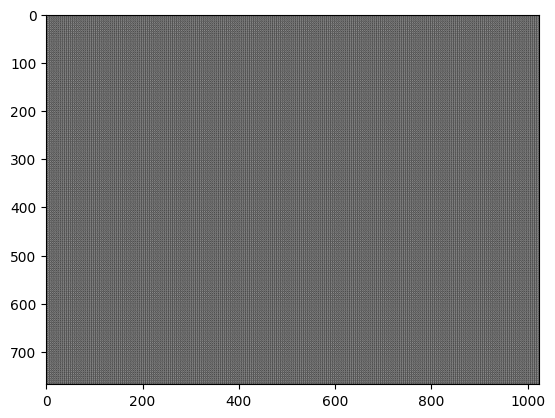

In [1988]:
import random 

index_pred = random.randint(0, len(noisy_images_to_predict)- 1)
# Example usage:

print("The sample number", index_pred)
image_to_predict = noisy_images_to_predict[index_pred]  # Example noisy image
denoised_image_predict = denoise_image(image_to_predict)

plt.imshow(denoised_image_predict, cmap="gray")

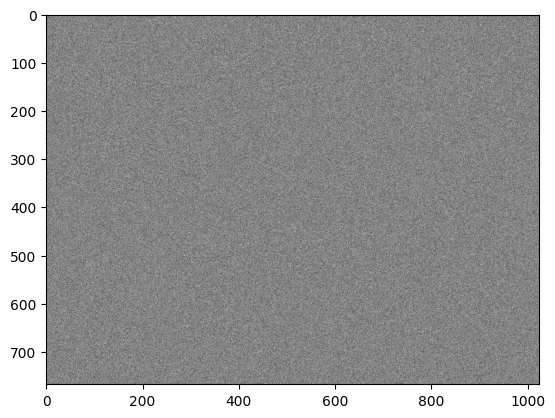

In [1989]:
plt.imshow(image_to_predict, cmap="gray")

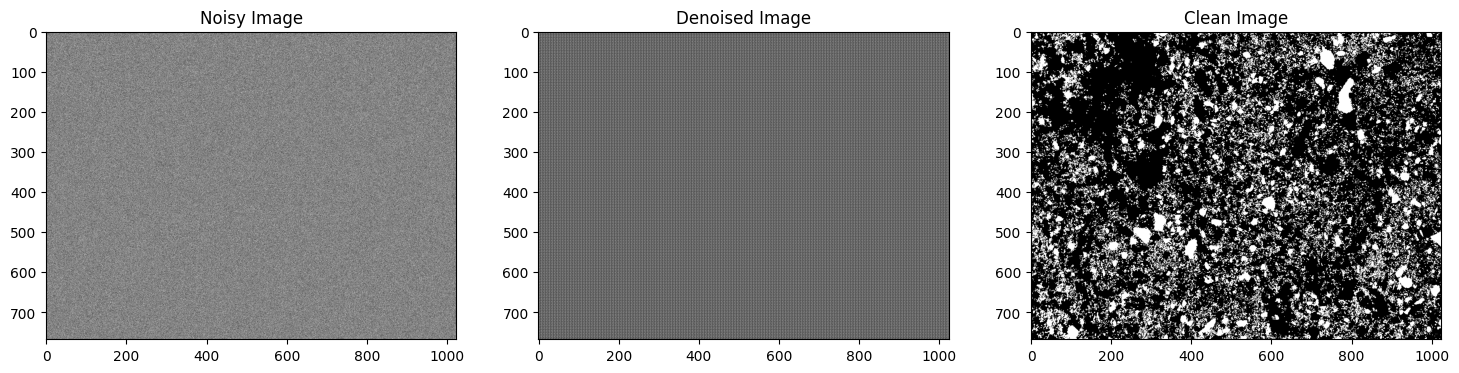

In [1990]:
# Plot the original noisy image, the denoised image, and the clean image
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Noisy Image")
plt.imshow(image_to_predict.squeeze(), cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Denoised Image")
plt.imshow(denoised_image_predict.squeeze(), cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Clean Image")
plt.imshow(clean_images[0].squeeze(), cmap="gray")

plt.show()

In [1991]:
denoised_image_predict.shape, denoised_image_predict.max(), denoised_image_predict.min()

((768, 1024, 1), 0.9273336, 0.11233334)

## Preprocessing of the data: CGAN

The first great result was: apply the normalize (not) the image segmentation(yes) and noise = 0.05

In [2266]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [2267]:
im_or = cv2.imread("PirabasB_2 - Copy.tif")

In [2268]:
im_or.shape


(768, 1024, 3)

In [2269]:
im_or.min(), im_or.max()

(0, 255)

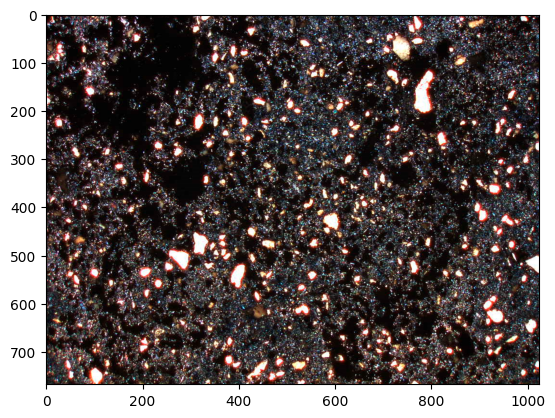

In [2270]:
plt.imshow(im_or)

In [2271]:
import cv2
# Convert the image to grayscale
grayscale_image = cv2.cvtColor(im_or, cv2.COLOR_BGR2GRAY)

In [2272]:
grayscale_image.shape

(768, 1024)

In [2273]:
grayscale_image.min(), grayscale_image.max()

(0, 255)

In [2274]:
norm_true = 0
if norm_true == 1:
    grayscale_image = (grayscale_image - grayscale_image.min())/ (grayscale_image.max() - grayscale_image.min())
    print("The data was normalized")
else:
    print("The data was not normalized")    

The data was not normalized


In [2275]:
grayscale_image.min(), grayscale_image.max()

(0, 255)

### Apply the segmentation with Thresold


In [2276]:
def create_binary(img):
    import cv2
    # Apply a threshold to the grayscale image
    #threshold_value = 95
    threshold_value = img.mean() + 0.24 * img.mean()
    max_value = 1
    # Set the value 1 to be the pore space
    ret, binary = cv2.threshold(img, threshold_value, max_value, cv2.THRESH_BINARY)
    return binary

In [2277]:
segmentation_proc = 1
if segmentation_proc == 1:
    grayscale_image = create_binary(grayscale_image)
    print("The image was segmentated with thresold")
else:
    print("The image was not segmentated with thresold")    
    
    
    

The image was segmentated with thresold


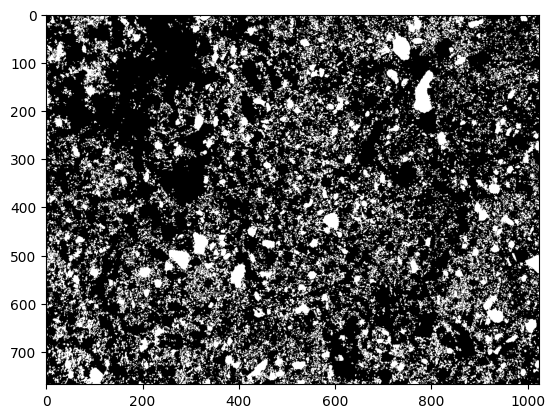

In [2278]:
plt.imshow(grayscale_image, cmap="gray")

### generate the samples with noise

In [2279]:
import numpy as np

def forward_process(image, timesteps, beta, norm_true):
    noisy_images = []
    for t in range(timesteps):
        noise = np.random.normal(0, beta, image.shape)
        image = image + noise
        if norm_true == 1:
            image = (image - image.min())/ (image.max() - image.min())
            #print("The data was normalized")
        else:
            False
            #print("The data was not normalized") 
        
        
        noisy_images.append(image)
    return noisy_images

def reverse_process(noisy_images, model):
    for t in reversed(range(len(noisy_images))):
        noisy_image = noisy_images[t]
        noise_estimate = model.predict(noisy_image)  # Modelo treinado para prever o ruído
        noisy_image = noisy_image - noise_estimate
    return noisy_image

In [2280]:
import numpy as np

def samples_generate_clean_process(image, timesteps, beta):
    clean_images = []
    for t in range(timesteps):
        clean_images.append(image)
    return clean_images


In [2281]:
# Process de difusão progressiva
# Exemplo de uso
timesteps = 75 # We have the 200 samples
timesteps_clean = 100
beta = 0.05
# A great beta is between 1 and 0

noisy_images = forward_process(grayscale_image, timesteps, beta, norm_true)
clean_images = samples_generate_clean_process(grayscale_image, timesteps_clean, beta)

In [2282]:
len(noisy_images)

75

In [2283]:
noisy_images = np.array(noisy_images)
clean_images = np.array(clean_images)
noisy_images.shape, clean_images.shape

((75, 768, 1024), (100, 768, 1024))

In [2284]:
## Check the range values to normalize the data
clean_images.min(), clean_images.max(), noisy_images.min() , noisy_images.max()

(0, 1, -2.0401018802414246, 3.0618148549912294)

In [2285]:
len(clean_images)

100

75


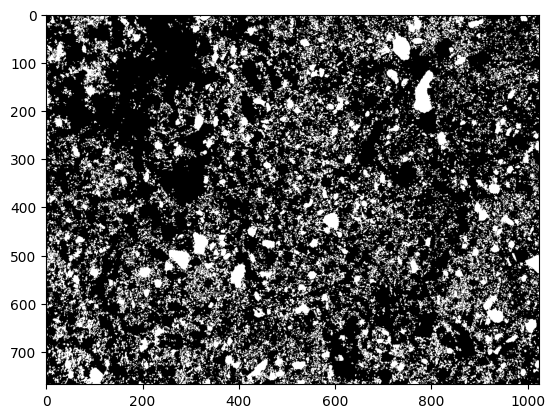

In [2286]:
import random 
idx_show_samples = random.randint(0,len(clean_images)) # without range incluse the max values 
print(idx_show_samples)
plt.imshow(clean_images[idx_show_samples, :, :], cmap="gray")

54


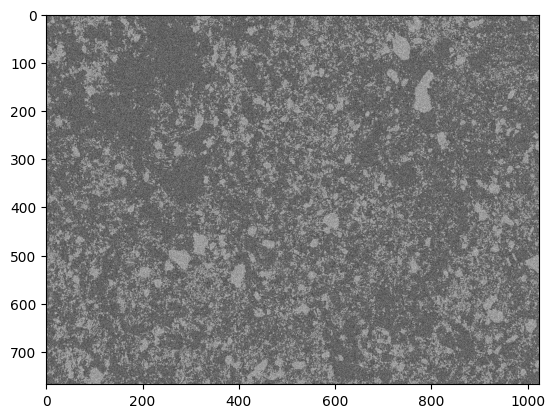

In [2287]:
import random 
idx_show_samples = random.randint(0,len(noisy_images)-1) # without range incluse the max values 
print(idx_show_samples)
plt.imshow(noisy_images[idx_show_samples, :, :], cmap="gray")

In [2288]:
## Check the range values to normalize the data
clean_images.min(), clean_images.max(), noisy_images.min() , noisy_images.max()

(0, 1, -2.0401018802414246, 3.0618148549912294)

In [2289]:
import tensorflow as tf
import numpy as np
import random
import os

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
def make_deterministic(seed=42):
    set_seed(seed)
    
    # Configurar TensorFlow para comportamento determinístico
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    session_config = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
    session_config.gpu_options.allow_growth = True
    session_config.gpu_options.force_gpu_compatible = True
    tf.compat.v1.keras.backend.set_session(tf.compat.v1.Session(config=session_config))

# Chamando a função para configurar a semente e o comportamento determinístico
make_deterministic(42)


## cGAN or pix2pix

In [2290]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, BatchNormalization, ReLU, Concatenate
from tensorflow.keras.models import Model

def build_generator(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Encoder
    e1 = Conv2D(64, kernel_size=4, strides=2, padding='same')(inputs)
    e2 = ReLU()(e1)
    e3 = BatchNormalization()(e2)
    e4 = Conv2D(128, kernel_size=4, strides=2, padding='same')(e3)
    
    # Decoder
    d1 = ReLU()(e4)
    d2 = BatchNormalization()(d1)
    d3 = Conv2DTranspose(64, kernel_size=4, strides=2, padding='same')(d2)
    d4 = Concatenate()([d3, e2])
    d5 = Conv2DTranspose(1, kernel_size=4, strides=2, padding='same', activation='tanh')(d4)
    
    return Model(inputs, d5)

input_shape = (768, 1024, 1)
generator = build_generator(input_shape)

In [2291]:
from tensorflow.keras.layers import Input, Concatenate, LeakyReLU, Dropout, Flatten, Dense

def build_discriminator(input_shape):
    noisy_image = Input(shape=input_shape)
    clean_image = Input(shape=input_shape)
    
    combined_images = Concatenate()([noisy_image, clean_image])
    
    d = Conv2D(64, kernel_size=4, strides=2, padding='same')(combined_images)
    d = LeakyReLU(alpha=0.2)(d)
    d = Dropout(0.5)(d)
    d = Conv2D(128, kernel_size=4, strides=2, padding='same')(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = Dropout(0.5)(d)
    d = Flatten()(d)
    d = Dense(1, activation='sigmoid')(d)
    
    return Model([noisy_image, clean_image], d)

discriminator = build_discriminator(input_shape)
discriminator.compile(optimizer='adam', loss='binary_crossentropy')


In [2292]:
# Freeze the discriminator when training the generator
discriminator.trainable = False

noisy_input = Input(shape=input_shape)
generated_image = generator(noisy_input)
validity = discriminator([noisy_input, generated_image])

gan = Model(noisy_input, validity)
gan.compile(optimizer='adam', loss=['binary_crossentropy', 'mse'], loss_weights=[1, 100])


In [2298]:
import numpy as np

with tf.device('/GPU:0'):
    def train_gan(generator, discriminator, gan, noisy_images, clean_images, epochs, batch_size):
        for epoch in range(epochs):
            for batch in range(int(noisy_images.shape[0] / batch_size)):
                # Select a random batch of images
                idx = np.random.randint(0, noisy_images.shape[0], batch_size)
                noisy_batch = noisy_images[idx]
                clean_batch = clean_images[idx]
            
                # Generate fake clean images
                generated_images = generator.predict(noisy_batch)
            
                # Train the discriminator
                d_loss_real = discriminator.train_on_batch([noisy_batch, clean_batch], np.ones((batch_size, 1)))
                d_loss_fake = discriminator.train_on_batch([noisy_batch, generated_images], np.zeros((batch_size, 1)))
                d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
            
                # Train the generator
                g_loss = gan.train_on_batch(noisy_batch, [np.ones((batch_size, 1)), clean_batch])
            
                # Print the progress
                d_loss_value = d_loss if isinstance(d_loss, float) else d_loss[0]
                g_loss_value = g_loss if isinstance(g_loss, float) else g_loss[0]
                print(f"{epoch} [D loss: {d_loss_value}] [G loss: {g_loss_value}]")

# Example usage:
# Assuming noisy_images and clean_images are numpy arrays of shape (100, 768, 1024, 1)

train_gan(generator, discriminator, gan, noisy_images, clean_images, epochs=10, batch_size=16)

1/1 [==============================] - 0s 44ms/step
0 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 31ms/step
0 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 31ms/step
0 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 32ms/step
0 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 33ms/step
1 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 33ms/step
1 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 31ms/step
1 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 31ms/step
1 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 33ms/step
2 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 32ms/step
2 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 32ms/step
2 [D loss: 0.0] [G loss: 0.0]
1/1 [==============================] - 0s 35ms/step
2 [D loss: 0.0] [G loss: 0.0]
1/1 [===========

The sample number 139
1/1 [==============================] - 0s 18ms/step


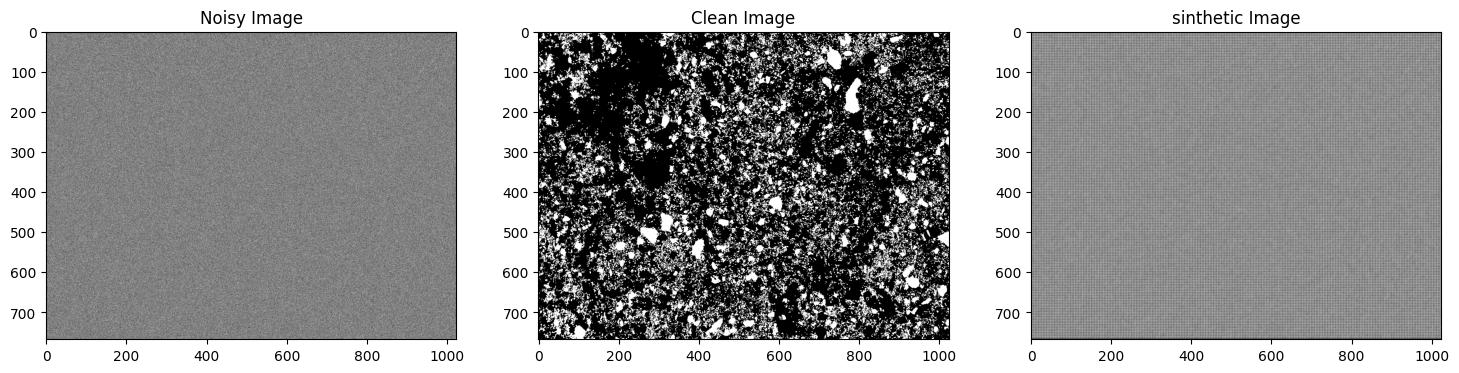

In [2299]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Assuming your generator is trained and noisy_images_to_predict is the tensor of noisy images

# Function to denoise an image using the trained generator
def denoise_image(generator, image):
    # Add batch dimension and predict
    image = np.expand_dims(image, axis=0)  # Shape (1, 768, 1024, 1)
    denoised_image = generator.predict(image)
    # Remove batch dimension
    denoised_image = np.squeeze(denoised_image, axis=0)  # Shape (768, 1024, 1)
    return denoised_image

# Example usage
index_pred = random.randint(0, len(noisy_images_to_predict) - 1)
index_pred = 139
print("The sample number", index_pred)
image_to_predict = noisy_images_to_predict[index_pred]  # Example noisy image
denoised_image_predict = denoise_image(generator, image_to_predict)

# Plot the original noisy image, the denoised image, and the clean image
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Noisy Image")
plt.imshow(image_to_predict, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Clean Image")
plt.imshow(clean_images[0], cmap="gray")

plt.subplot(1, 3, 3)
plt.title("sinthetic Image")
plt.imshow(denoised_image_predict, cmap="gray")

plt.show()

The sample number 139
1/1 [==============================] - 0s 17ms/step


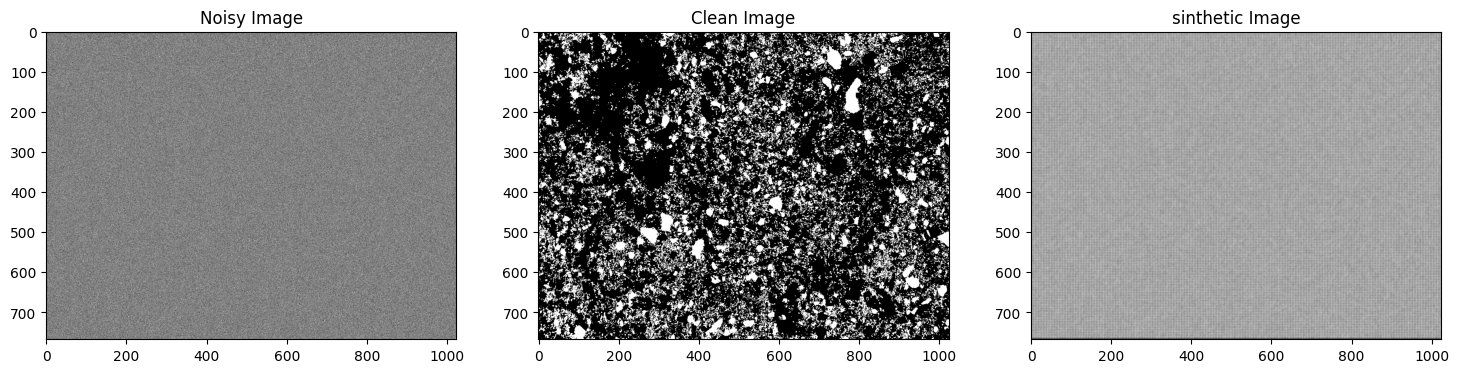

In [2296]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Assuming your generator is trained and noisy_images_to_predict is the tensor of noisy images

# Function to denoise an image using the trained generator
def denoise_image(generator, image):
    # Add batch dimension and predict
    image = np.expand_dims(image, axis=0)  # Shape (1, 768, 1024, 1)
    denoised_image = generator.predict(image)
    # Remove batch dimension
    denoised_image = np.squeeze(denoised_image, axis=0)  # Shape (768, 1024, 1)
    return denoised_image

# Example usage
index_pred = random.randint(0, len(noisy_images_to_predict) - 1)
print("The sample number", index_pred)
image_to_predict = noisy_images_to_predict[index_pred]  # Example noisy image
denoised_image_predict = denoise_image(generator, image_to_predict)

# Plot the original noisy image, the denoised image, and the clean image
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Noisy Image")
plt.imshow(image_to_predict, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Clean Image")
plt.imshow(clean_images[0], cmap="gray")

plt.subplot(1, 3, 3)
plt.title("sinthetic Image")
plt.imshow(denoised_image_predict, cmap="gray")

plt.show()